# 2일차 실습 P8 — 점수의 눈금 · 글자 칸으로 판단하기

- 끝 조건: 확인 셀 통과 + 맨 아래 마무리 칸에 자기 말로 한 문장 — 왜 글자 칸 표시를 clean 으로 만들었나
- **맨 위 준비 셀부터** 위에서 아래로 실행
- 셀 실행: 셀을 누르고 **Shift + Enter** 또는 셀 왼쪽 ▶
- Colab 에서 처음 열 때 경고 창이 뜨면 '계속' · 데이터는 내려받지 않음 · 준비 셀 · 문서 셀이 연습용 합성 문서를 만듦
- 모델 셀은 P6 과 같은 짝으로 10 에폭 학습함 · `맞춘 짝  학습 끝` 줄이 찍힐 때까지 기다림
- 빈칸은 `____` · 빈칸을 모두 바꾼 뒤 **그 셀부터 다시 실행**
- 막히면 `[안내]` 문장 → **에러 칸 맨 아래 줄** → 힌트 순서로 읽음
- 과제 셀에서 빨간 문법·실행 오류가 나면 확인 셀을 믿지 말 것 · 과제 셀을 고쳐 정상 실행한 뒤 확인 셀을 다시 실행할 것

## 에러를 읽는 법

- 에러 칸 첫 줄(`...Error    Traceback ...`)은 제목일 뿐 · 무엇이 틀렸는지는 **맨 아래 줄**
- 중간의 `---->` 화살표 줄 · numpy · torch 안쪽 칸은 처음엔 건너뜀 · **위에 찍힌 `[안내]` 문장과 맨 아래 줄부터** 읽음

| 맨 아래 줄에 보이는 말 | 뜻 | 먼저 볼 곳 |
|---|---|---|
| `name '____' is not defined` | 빈칸이 남음 | 화살표가 가리키는 줄 |
| `name 'eval_clean' is not defined` | 평가 함수 · 평가 문서 셀을 안 돌렸거나 런타임이 끊김 | 준비 셀부터 순서대로 다시 |
| `ones_like(): argument 'input' (position 1) must be Tensor, not numpy.ndarray` | 괄호 안에 넣은 것이 텐서가 아님 · docs 에서 바로 꺼낸 판은 numpy 배열 | ① 줄의 괄호 안 |
| `name 'Clean' is not defined` | 내가 친 이름이 틀림 · 대소문자 · 이 셀에서 쓰는 이름은 모두 소문자 | 화살표가 가리키는 줄 |

- **에러가 없는데** 확인 셀이 `[안내]` 를 찍으면 → 그 문장이 가리키는 줄부터
- 과제 셀에서 빨간 문법·실행 오류가 나면 확인 셀을 믿지 말 것 · 과제 셀을 고쳐 정상 실행한 뒤 확인 셀을 다시 실행할 것
- 결과 셀 맨 아래 줄이 `AssertionError: [안내] 확인 ① · ② …` → 확인 셀을 먼저 · P8-1 · P8-2 셀을 다시 실행했으면 그 확인 셀도 다시

## 준비

합성 문서 만들기 · 조각 자르기 · 모델 · 학습 함수 · 그림 함수 · 고치지 않고 실행

In [1]:
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

plt.rcParams.update({"figure.facecolor": "#1A222C", "axes.facecolor": "#1A222C", "savefig.facecolor": "#1A222C",   # 그림을 어두운 화면에 맞춤
                     "text.color": "#EEF2F6", "axes.labelcolor": "#EEF2F6", "xtick.color": "#EEF2F6", "ytick.color": "#EEF2F6", "axes.edgecolor": "#5C6A78"})

# ── 합성 문서 만들기 · 고치지 않고 실행 · 읽지 않아도 됨 ──
WORDS = ("the of and to in is was for on that with as by at from this be are or an report data model image paper result "
         "note page table value error clean noise sample layer filter record method letter number office meeting account "
         "review summary budget project quality section figure total").split()


def make_doc(seed, h=128, w=256, kinds=("gradient", "occlude", "saltpepper")):
    """문서 번호 하나 → (clean, dirty) · 값 0~1 · 같은 번호는 늘 같은 문서"""
    rng = np.random.default_rng(seed)
    size = int(rng.integers(12, 20))
    img = Image.new("L", (w, h), 255)
    draw = ImageDraw.Draw(img)
    font = ImageFont.load_default(size=size)
    y = int(rng.integers(2, max(3, size // 2)))
    while y + int(size * 1.45) <= h - 2:                      # 줄마다 단어를 이어 씀
        x, words = int(rng.integers(2, 12)), []
        while True:
            cand = " ".join(words + [WORDS[int(rng.integers(len(WORDS)))]])
            if x + draw.textlength(cand, font=font) > w - 4:
                break
            words = cand.split()
        if words:
            draw.text((x, y), " ".join(words), fill=0, font=font)
        y += int(size * 1.45)
    clean = np.asarray(img, dtype=np.float32) / 255.0
    d = clean.copy()
    if "gradient" in kinds:                                   # 한쪽으로 갈수록 어두워짐
        g = np.linspace(0, rng.uniform(0.1, 0.35), w, dtype=np.float32)[None, :]
        if rng.random() < 0.5:
            g = g[:, ::-1]
        d = d * (1 - g)
    if "occlude" in kinds:                                    # 회색 상자가 글자를 가림
        oh, ow = int(h * rng.uniform(0.1, 0.25)), int(w * rng.uniform(0.05, 0.15))
        oy, ox = int(rng.integers(0, h - oh)), int(rng.integers(0, w - ow))
        d[oy:oy + oh, ox:ox + ow] = rng.uniform(0.2, 0.6)
    if "saltpepper" in kinds:                                 # 검은 점 · 흰 점
        m = rng.random(d.shape)
        p = rng.uniform(0.002, 0.01)
        d[m < p / 2] = 0.0
        d[m > 1 - p / 2] = 1.0
    return clean, np.clip(d, 0, 1).astype(np.float32)


# ── 오늘 쓰는 크기 · 문서 번호 · 도구 ──
H, W, PS = 128, 256, 48                 # 문서 세로 · 가로 · 조각 한 변
train_ids = list(range(1000, 1024))     # 학습 문서 24장
eval_ids = list(range(2000, 2008))      # 평가 문서 8장 · 학습에 쓰지 않음


def crop(img, y, x):                    # (y, x) 를 왼쪽 위 모서리로 삼아 48×48 조각을 잘라 냄
    return img[y:y + PS, x:x + PS]


def to_batch(patches):                  # 조각 목록 → (조각 수, 1, 48, 48) 텐서
    return torch.tensor(np.stack(patches)).unsqueeze(1)


def make_model():                       # 1일차 Conv 오토인코더와 같은 구성 · 48 → 24 → 12 → 24 → 48
    return nn.Sequential(
        nn.Conv2d(1, 16, 3, 2, 1), nn.ReLU(),
        nn.Conv2d(16, 32, 3, 2, 1), nn.ReLU(),
        nn.ConvTranspose2d(32, 16, 3, 2, 1, output_padding=1), nn.ReLU(),
        nn.ConvTranspose2d(16, 1, 3, 2, 1, output_padding=1), nn.Sigmoid())


def train(X, Y, name, epochs=10):       # 입력 X · 정답 Y 로 학습 · 에폭마다 loss 한 줄
    torch.manual_seed(0)                # 모델마다 같은 출발점
    model = make_model()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    t = time.time()
    for epoch in range(1, epochs + 1):
        perm = torch.randperm(len(X))
        total = 0.0
        for k in range(0, len(X), 32):
            b = perm[k:k + 32]
            opt.zero_grad()
            loss = F.mse_loss(model(X[b]), Y[b])
            loss.backward()
            opt.step()
            total += loss.item() * len(b)
        print(f"{name}  에폭 {epoch:>2}  loss {total / len(X):.4f}")
    print(f"{name}  학습 끝 ({time.time() - t:.0f}초)")
    return model


def show_rows(rows, idx):               # rows = [(줄 이름, 조각 묶음), …] · 줄마다 같은 번호의 조각
    fig, axes = plt.subplots(len(rows), len(idx), figsize=(len(idx), 1.25 * len(rows)))
    for r, (name, T) in enumerate(rows):
        for c, j in enumerate(idx):
            axes[r, c].imshow(T[j, 0], cmap="gray", vmin=0, vmax=1)
            axes[r, c].axis("off")
        axes[r, 0].set_title(name, loc="left", fontsize=10)
    plt.tight_layout()
    plt.show()

## 문서

학습 문서 24장 · 평가 문서 8장 · 문서 1000 한 쌍 그림 · 고치지 않고 실행

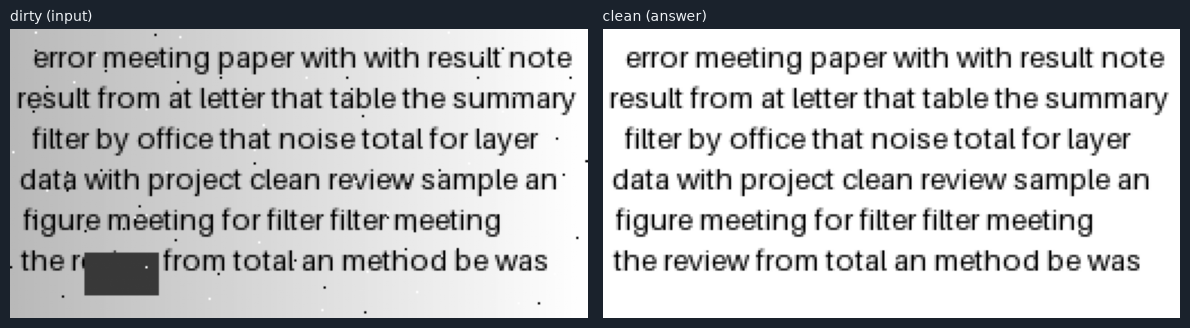

문서 32 장 · 한 장 크기 (128, 256)


In [3]:
docs = {i: make_doc(i) for i in train_ids + eval_ids}   # 문서 번호 → (clean, dirty)
clean, dirty = docs[1000]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
for ax, (name, img) in zip(axes, [("dirty (input)", dirty), ("clean (answer)", clean)]):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(name, loc="left", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()
print("문서", len(docs), "장 · 한 장 크기", clean.shape)

## 맞춘 짝 모델

P6 과 같은 짝 · 같은 학습(10 에폭 · 시드 0) · 고치지 않고 실행

In [5]:
# 맞춘 짝 모델 — P6 과 같은 짝(학습 문서 24장 · 문서마다 좌표 128개 · seed 2026) · 같은 학습(10 에폭 · 시드 0) · 고치지 않고 실행
rng = np.random.default_rng(2026)
X, Y_A = [], []
for i in train_ids:
    c, d = docs[i]
    ys, xs = rng.integers(0, H - PS + 1, 128), rng.integers(0, W - PS + 1, 128)
    for y, x in zip(ys, xs):
        X.append(crop(d, y, x))
        Y_A.append(crop(c, y, x))
model_A = train(to_batch(X), to_batch(Y_A), "맞춘 짝").eval()

맞춘 짝  에폭  1  loss 0.1025
맞춘 짝  에폭  2  loss 0.0512
맞춘 짝  에폭  3  loss 0.0276
맞춘 짝  에폭  4  loss 0.0175
맞춘 짝  에폭  5  loss 0.0131
맞춘 짝  에폭  6  loss 0.0107
맞춘 짝  에폭  7  loss 0.0093
맞춘 짝  에폭  8  loss 0.0084
맞춘 짝  에폭  9  loss 0.0077
맞춘 짝  에폭 10  loss 0.0073
맞춘 짝  학습 끝 (8초)


## 평가 함수 · 평가 문서

- `rmse_doc(outs, cleans)` — 문서마다 RMSE(원본과의 차이 · 작을수록 원본에 가까움) → 문서 수만큼 평균
- 평가 문서 8장을 한 장씩 통째로 모델에 넣음 · 모델 출력 · 정답 · 손상판 목록 세 개를 만듦 · 고치지 않고 실행

In [6]:
def rmse_doc(outs, cleans):                   # 문서마다 RMSE → 평균
    return float(np.mean([np.sqrt(((np.asarray(o) - np.asarray(c)) ** 2).mean()) for o, c in zip(outs, cleans)]))


with torch.no_grad():
    outs = {i: model_A(torch.tensor(docs[i][1])[None, None])[0, 0] for i in docs}   # 문서 32장을 한 장씩 통째로 복원 · 문서 번호 → 모델 출력
eval_out = [outs[i] for i in eval_ids]                       # 평가 문서 8장 · 모델 출력
eval_clean = [torch.tensor(docs[i][0]) for i in eval_ids]    # 평가 문서 8장 · 정답
eval_dirty = [torch.tensor(docs[i][1]) for i in eval_ids]    # 평가 문서 8장 · 손상판
print("평가 문서", len(eval_out), "장 · 한 장 모양", tuple(eval_out[0].shape), "· 재는 단위: 문서 한 장마다 RMSE → 8장 평균")

평가 문서 8 장 · 한 장 모양 (128, 256) · 재는 단위: 문서 한 장마다 RMSE → 8장 평균


## P8-1. 점수의 눈금

손상 그대로 · 흰 종이 · 내 모델을 **같은 함수 · 같은 평가 문서 8장**으로 잼

1. 아래 셀의 빈칸 두 곳을 채움
   - ① 문서 한 장과 같은 모양이고 모든 칸이 1(흰색)인 종이 · `torch.ones_like(…)` 괄호 안에는 모양을 따를 문서 한 장
   - ② 모델이 복원한 평가 문서 목록의 이름
2. 실행 → 세 줄(문서 RMSE)이 찍힘 → 아래 **확인 ①** 셀 실행 → `눈금 확인 통과` 가 나오면 P8-2 로 · **P8-1 셀을 다시 실행했으면 확인 ① 도 다시**
- 확인 셀이 `[안내]` 를 찍으면 그 문장부터 읽음 · 막히면 코드 셀 아래 **힌트 1** → **힌트 2** 순서로 하나씩 펼침
- 그래도 막히면 확인 ① 아래 **대체 셀 ①** 을 실행하고 P8-2 로

In [13]:
# 문법 예시 (이 실습의 답 아님)
#   torch.full_like(a, 0.5)          → a 와 같은 모양 · 모든 칸이 0.5 인 텐서
#   rmse_doc(목록1, 목록2)            → 두 목록에서 같은 자리 문서끼리 RMSE → 평균

white_docs = 표 = None                            # 이 셀을 실행할 때마다 이전 결과를 지움 · 고치지 않음
눈금_통과 = 대체_사용 = False                      # 확인 셀 통과 표시 · 대체 셀 사용 표시 · 고치지 않음

white_docs = []
for clean, dirty in zip(eval_clean, eval_dirty):  # 평가 문서 8장을 한 장씩
    white_docs.append(torch.ones_like(clean))      # ① 이 문서와 같은 모양 · 모든 칸이 1(흰색)인 종이 한 장

표 = {"손상 그대로": rmse_doc(eval_dirty, eval_clean),
      "흰 종이": rmse_doc(white_docs, eval_clean),
      "내 모델": rmse_doc(eval_out, eval_clean)}      # ② 모델이 복원한 평가 문서 목록
for name, v in 표.items():
    print(f"{name:<6}  문서 RMSE {v:.3f}   (평가 문서 8장 · 문서별 평균)")

손상 그대로  문서 RMSE 0.152   (평가 문서 8장 · 문서별 평균)
흰 종이    문서 RMSE 0.297   (평가 문서 8장 · 문서별 평균)
내 모델    문서 RMSE 0.069   (평가 문서 8장 · 문서별 평균)


<details><summary><b>힌트 1</b> — 막힐 때만 펼침</summary>

- ① 반복 줄 `for clean, dirty in …` 이 평가 문서를 한 장씩 꺼내 줌 · 괄호 안에는 그렇게 꺼낸 문서 한 장의 이름
- ② 위 **평가 함수 · 평가 문서** 셀이 만든 목록 세 개 가운데 모델 출력 목록

</details>

<details><summary><b>힌트 2</b> — 힌트 1 로도 막힐 때</summary>

- ① `torch.ones_like(clean)`
- ② `rmse_doc(eval_out, eval_clean)` 의 첫 자리

</details>

In [14]:
# P8-1 확인 ① — 흰 종이 · 세 값 검사 · 고치지 않고 실행만 · 읽지 않아도 됨
# 약속(수업 설명과 같음): 평가 문서 2000~2007 · 흰 종이 = 문서 한 장과 같은 모양 · 모든 칸 1 · 세 값 모두 문서마다 RMSE → 8장 평균
def 과제_문법_검사(*표시):                       # 과제 셀을 마지막으로 실행한 글자에 문법 오류가 있었는지 · 실행 기록(In)이 없으면 통과하지 않음
    기록 = globals().get("In")
    if not isinstance(기록, list) or len(기록) < 2:
        return False
    for 표 in 표시:
        for src in reversed(기록[:-1]):
            if 표 in src and "def 과제_문법_검사" not in src:
                try:
                    compile(src, "<과제 셀>", "exec")
                except SyntaxError:
                    return False
                break
    return True


def 문서별_rmse(outs, cleans):                      # 기준 계산 · 위 rmse_doc 를 고쳐도 속지 않게 따로 계산
    return float(np.mean([np.sqrt(((np.asarray(o) - c) ** 2).mean()) for o, c in zip(outs, cleans)]))


def 눈금_검사(white_docs, 표):
    if white_docs is None or 표 is None:
        return "[안내] 위 P8-1 셀이 끝까지 실행되지 않았음 → 빈칸 ____ 두 곳을 모두 바꾸고 P8-1 셀부터 다시 실행 · 위 셀들을 안 돌렸으면 준비 셀부터"
    정답 = [make_doc(i)[0] for i in range(2000, 2008)]            # 문서를 새로 만들어 비교
    손상 = [make_doc(i)[1] for i in range(2000, 2008)]
    with torch.no_grad():
        복원 = [model_A(torch.tensor(d)[None, None])[0, 0].numpy() for d in 손상]
        학습문서_복원 = [model_A(torch.tensor(make_doc(i)[1])[None, None])[0, 0].numpy() for i in range(1000, 1008)]
    같음 = lambda a, b: abs(float(a) - float(b)) <= 1e-5 * max(abs(float(b)), 1e-3)
    if len(white_docs) != 8:
        return f"[안내] 흰 종이가 {len(white_docs)}장 · 평가 문서 8장과 같은 수여야 함"
    for w in white_docs:
        w = np.asarray(w)
        if w.shape != (128, 256):
            return f"[안내] 흰 종이 한 장 모양 {w.shape} 이 문서 한 장 모양 (128, 256) 과 다름 → ① 괄호 안은 문서 한 장"
        if not np.all(w == 1):
            if np.all(w == 0):
                return "[안내] 흰 종이 대신 검은 종이(모든 칸 0) → 흰색은 1"
            return "[안내] 흰 종이의 칸 값이 모두 1 이 아님 → 흰색 = 1"
    if set(표) != {"손상 그대로", "흰 종이", "내 모델"}:
        return "[안내] 표의 이름 세 개는 고치지 않음"
    if not (같음(표["손상 그대로"], 문서별_rmse(손상, 정답)) and 같음(표["흰 종이"], 문서별_rmse([np.ones(c.shape) for c in 정답], 정답))):
        return "[안내] 손상 그대로 · 흰 종이 값이 평가 문서 8장으로 잰 값과 다름 → 빈칸 두 곳 말고 다른 곳은 고치지 않음"
    v = 표["내 모델"]
    if 같음(v, 문서별_rmse(복원, 정답)):
        return "눈금 확인 통과"
    if 같음(v, 문서별_rmse(학습문서_복원, 정답)):
        return "[안내] 내 모델 값을 학습 문서의 복원 결과로 쟀음 → 평가 문서 8장의 복원 결과로 잼"
    if 같음(v, 문서별_rmse(손상, 정답)):
        return "[안내] 내 모델 값이 손상 그대로와 같음 → ② 에는 모델이 복원한 목록"
    if abs(float(v)) < 1e-9:
        return "[안내] 내 모델 값이 0 → 정답끼리 비교했음 · ② 에는 모델이 복원한 목록"
    return "[안내] 내 모델 값이 평가 문서 8장 복원 결과로 잰 값과 다름 → ② 목록"


결과 = 눈금_검사(globals().get("white_docs"), globals().get("표")) if 과제_문법_검사('white_docs = 표 = None') else "[안내] 과제 셀의 정상 실행을 확인할 수 없음(문법 오류 또는 실행 기록 없음) · 과제 셀을 고쳐 정상 실행한 뒤 확인 셀을 다시 실행 · 계속되면 런타임을 다시 시작하고 준비부터 실행"
눈금_통과 = 결과 == "눈금 확인 통과"                # 통과를 찍을 때만 True · 결과 셀이 이 값을 봄
눈금_출처 = "대체 셀" if globals().get("대체_사용") else "직접 잼"
print(결과)

눈금 확인 통과


### 대체 셀 ① — 확인 ① 이 `[안내]` 를 찍었고 막혔을 때만 실행

- P8-1 과 같은 흰 종이 · 세 값을 다른 방법으로 만듦 · 실행하면 P8-2 로 넘어갈 수 있음
- `눈금 확인 통과` 가 나왔으면 실행하지 않음 · 실행하면 결과 셀 첫 줄에 `눈금: 대체 셀` 이 찍힘

In [ ]:
# 대체 셀 ① — 막혔을 때만 · P8-1 과 같은 white_docs · 표를 다른 방법으로 만듦
white_docs = [torch.full(tuple(docs[i][0].shape), 1.0) for i in eval_ids]
표 = dict(zip(["손상 그대로", "흰 종이", "내 모델"], [rmse_doc(v, eval_clean) for v in (eval_dirty, white_docs, eval_out)]))
for name, v in 표.items():
    print(f"대체 셀 ① · {name:<6}  문서 RMSE {v:.3f}   (평가 문서 8장 · 문서별 평균)")
눈금_통과, 대체_사용, 눈금_출처 = True, True, "대체 셀"   # 대체 셀 결과라는 표시 · P8-1 셀을 다시 실행하면 지워짐

## P8-2. 글자 칸만 재기

문서에서 글자 칸만 골라 차이를 잼 · 글자 칸 = 어두운 칸(0.5 보다 작은 칸)

1. 아래 셀의 빈칸 ③ 을 채움 · `text_mask` 는 평가 문서 한 장의 정답 `clean` · 손상판 `dirty` · 모델 출력 `out` 을 받음 · 이 가운데 **어느 판의 어두운 칸**을 글자 칸으로 삼나
2. 실행 → 두 줄(글자 칸 RMSE)이 찍힘 → 아래 **확인 ②** 셀 실행 → `글자 칸 확인 통과` 가 나오면 결과로 · **P8-2 셀을 다시 실행했으면 확인 ② 도 다시**
- 확인 셀이 `[안내]` 를 찍으면 그 문장부터 읽음 · 막히면 코드 셀 아래 **힌트 1** → **힌트 2** 순서로 하나씩 펼침
- 그래도 막히면 확인 ② 아래 **대체 셀 ②** 를 실행하고 결과로

In [21]:
# 문법 예시 (이 실습의 답 아님)
#   a = torch.tensor([0.2, 0.9, 0.4])  다음  a < 0.5   → tensor([True, False, True]) · 칸마다 0.5 보다 작은지

text_mask = 글자표 = None                         # 이 셀을 실행할 때마다 이전 결과를 지움 · 고치지 않음
글자칸_통과 = 대체_사용 = False                    # 확인 셀 통과 표시 · 대체 셀 사용 표시 · 고치지 않음


def text_mask(clean, dirty, out):                 # 평가 문서 한 장의 정답 · 손상판 · 모델 출력 → 글자 칸 표시(True = 글자 칸)
    mask = clean < 0.5                             # ③ 글자 칸 = 어두운 칸 · 어느 판에서 고르나
    return mask


def rmse_text(outs, cleans, dirties):             # 문서마다 글자 칸만 모아 RMSE → 평균 · 고치지 않음
    vals = []
    for o, c, d in zip(outs, cleans, dirties):
        m = np.asarray(text_mask(c, d, o))
        vals.append(np.sqrt(((np.asarray(o) - np.asarray(c))[m] ** 2).mean()))
    return float(np.mean(vals))


글자표 = {"손상 그대로": rmse_text(eval_dirty, eval_clean, eval_dirty), "내 모델": rmse_text(eval_out, eval_clean, eval_dirty)}
for name, v in 글자표.items():
    print(f"{name:<6}  글자 칸 RMSE {v:.3f}   (평가 문서 8장 · 글자 칸 · 문서별 평균)")

손상 그대로  글자 칸 RMSE 0.074   (평가 문서 8장 · 글자 칸 · 문서별 평균)
내 모델    글자 칸 RMSE 0.156   (평가 문서 8장 · 글자 칸 · 문서별 평균)


<details><summary><b>힌트 1</b> — 막힐 때만 펼침</summary>

- ③ 글자가 원래 어디 있었는지 가장 정확히 아는 판은 셋 가운데 하나 · 손상판은 가림 상자 · 어두워진 바탕 · 검은 점도 어두움 · 모델 출력은 흐려진 획이 밝아질 수 있음

</details>

<details><summary><b>힌트 2</b> — 힌트 1 로도 막힐 때</summary>

- ③ `mask = clean < 0.5`

</details>

In [22]:
# P8-2 확인 ② — 글자 칸 표시 검사 · 고치지 않고 실행만 · 읽지 않아도 됨
# 약속(수업 설명과 같음): 글자 칸 = 정답에서 0.5 보다 어두운 칸 · 평가 문서 2000~2007 · 문서마다 글자 칸 RMSE → 8장 평균
def 과제_문법_검사(*표시):                       # 과제 셀을 마지막으로 실행한 글자에 문법 오류가 있었는지 · 실행 기록(In)이 없으면 통과하지 않음
    기록 = globals().get("In")
    if not isinstance(기록, list) or len(기록) < 2:
        return False
    for 표 in 표시:
        for src in reversed(기록[:-1]):
            if 표 in src and "def 과제_문법_검사" not in src:
                try:
                    compile(src, "<과제 셀>", "exec")
                except SyntaxError:
                    return False
                break
    return True


def 글자칸_검사(text_mask, 글자표):
    if text_mask is None or 글자표 is None:
        return "[안내] 위 P8-2 셀이 끝까지 실행되지 않았음 → 빈칸 ____ 을 바꾸고 P8-2 셀부터 다시 실행 · 위 셀들을 안 돌렸으면 준비 셀부터"
    기준_손상, 기준_모델 = [], []
    for i in range(2000, 2008):
        c, d = make_doc(i)                          # 문서를 새로 만들어 비교
        with torch.no_grad():
            o = model_A(torch.tensor(d)[None, None])[0, 0].numpy()
        try:
            m = np.asarray(text_mask(torch.tensor(c), torch.tensor(d), torch.tensor(o)))
        except Exception as e:
            return f"[안내] 확인 셀이 text_mask 를 다시 불러 보다 멈춤({type(e).__name__}) → ③ 줄"
        if m.shape != c.shape or m.dtype != bool:
            return "[안내] 글자 칸 표시가 문서 한 장 모양의 True · False 가 아님 → ③ 줄은 판 이름 하나와 < 0.5"
        if not np.array_equal(m, c < 0.5):
            if np.array_equal(m, o < 0.5):
                return "[안내] 글자 칸을 모델 출력에서 골랐음 → 모델이 흐리게 낸 획은 글자 칸에서 빠짐 · 글자 칸은 정답에서"
            if np.array_equal(m, d < 0.5):
                return "[안내] 글자 칸을 손상판에서 골랐음 → 가림 상자 · 어두워진 바탕 · 검은 점까지 글자 칸이 됨 · 글자 칸은 정답에서"
            if np.array_equal(m, c > 0.5) or np.array_equal(m, c >= 0.5):
                return "[안내] 밝은 칸(바탕)을 골랐음 → 글자는 어두운 칸"
            if any(np.array_equal(m, c < t) or np.array_equal(m, c <= t) for t in np.arange(0.05, 1.0, 0.05)):
                return "[안내] 어두운 칸을 가르는 문턱이 약속(0.5)과 다름 → < 0.5 는 고치지 않음"
            return "[안내] 글자 칸 표시가 '정답에서 0.5 보다 어두운 칸' 과 다름 → ③ 줄"
        기준_손상.append(np.sqrt(((d - c)[c < 0.5] ** 2).mean()))
        기준_모델.append(np.sqrt(((o - c)[c < 0.5] ** 2).mean()))
    if set(글자표) != {"손상 그대로", "내 모델"}:
        return "[안내] 표의 이름 두 개는 고치지 않음"
    같음 = lambda a, b: abs(float(a) - float(b)) <= 1e-5 * max(abs(float(b)), 1e-3)
    if not (같음(글자표["손상 그대로"], np.mean(기준_손상)) and 같음(글자표["내 모델"], np.mean(기준_모델))):
        return "[안내] 글자 칸 RMSE 가 평가 문서 8장으로 잰 값과 다름 → 빈칸 말고 다른 곳은 고치지 않음"
    return "글자 칸 확인 통과"


결과 = 글자칸_검사(globals().get("text_mask"), globals().get("글자표")) if 과제_문법_검사('text_mask = 글자표 = None') else "[안내] 과제 셀의 정상 실행을 확인할 수 없음(문법 오류 또는 실행 기록 없음) · 과제 셀을 고쳐 정상 실행한 뒤 확인 셀을 다시 실행 · 계속되면 런타임을 다시 시작하고 준비부터 실행"
글자칸_통과 = 결과 == "글자 칸 확인 통과"           # 통과를 찍을 때만 True · 결과 셀이 이 값을 봄
글자칸_출처 = "대체 셀" if globals().get("대체_사용") else "직접 잼"
print(결과)

글자 칸 확인 통과


### 대체 셀 ② — 확인 ② 가 `[안내]` 를 찍었고 막혔을 때만 실행

- P8-2 와 같은 글자 칸 표시 · 글자 칸 RMSE 를 다른 방법으로 만듦 · 실행하면 결과로 넘어갈 수 있음
- `글자 칸 확인 통과` 가 나왔으면 실행하지 않음 · 실행하면 결과 셀 첫 줄에 `글자 칸: 대체 셀` 이 찍힘

In [ ]:
# 대체 셀 ② — 막혔을 때만 · P8-2 와 같은 text_mask · rmse_text · 글자표 를 다른 방법으로 만듦
def text_mask(clean, dirty, out):
    return torch.as_tensor(clean).lt(0.5)


def rmse_text(outs, cleans, dirties):
    vals = []
    for o, c, d in zip(outs, cleans, dirties):
        글자칸 = np.asarray(text_mask(c, d, o))
        vals.append(np.sqrt(np.mean((np.asarray(o)[글자칸] - np.asarray(c)[글자칸]) ** 2)))
    return float(np.mean(vals))


글자표 = {"손상 그대로": rmse_text(eval_dirty, eval_clean, eval_dirty), "내 모델": rmse_text(eval_out, eval_clean, eval_dirty)}
for name, v in 글자표.items():
    print(f"대체 셀 ② · {name:<6}  글자 칸 RMSE {v:.3f}   (평가 문서 8장 · 글자 칸 · 문서별 평균)")
글자칸_통과, 대체_사용, 글자칸_출처 = True, True, "대체 셀"   # 대체 셀 결과라는 표시 · P8-2 셀을 다시 실행하면 지워짐

## 결과 — 표 · 가장 나쁜 조각

아래 두 셀은 **고치지 않고** 차례로 실행 · 확인 ① · ② 통과(또는 대체 셀) 뒤에만 돎

1. **표**: 손상 그대로 · 흰 종이 · 내 모델 · 문서 전체 RMSE · 글자 칸 RMSE(평가 문서 8장 · 문서별 평균 · 작을수록 정답에 가까움) · 첫 줄에 출처
2. **가장 나쁜 조각 3개**: 평가 문서 조각 256개 가운데 모델 오차가 가장 큰 조각 · 줄마다 dirty · clean · model
- 표와 그림을 본 뒤 맨 아래 마무리 칸으로

In [23]:
# 결과 표 — 문서 전체 · 글자 칸 · 평가 문서 8장 · 문서별 평균 · 작을수록 정답에 가까움
assert globals().get("눈금_통과") and globals().get("글자칸_통과"), "[안내] 확인 ① · ② 에서 모두 통과를 받은 뒤 실행 · P8-1 · P8-2 셀을 다시 실행했으면 그 확인 셀도 다시 · 막히면 대체 셀"
print("눈금:", 눈금_출처, " · 글자 칸:", 글자칸_출처)
print(f"손상 그대로   문서 전체 RMSE {표['손상 그대로']:.3f}   글자 칸 RMSE {글자표['손상 그대로']:.3f}")
print(f"흰 종이       문서 전체 RMSE {표['흰 종이']:.3f}")
print(f"내 모델       문서 전체 RMSE {표['내 모델']:.3f}   글자 칸 RMSE {글자표['내 모델']:.3f}")
print("(평가 문서 8장 · 문서별 평균)")

눈금: 직접 잼  · 글자 칸: 직접 잼
손상 그대로   문서 전체 RMSE 0.152   글자 칸 RMSE 0.074
흰 종이       문서 전체 RMSE 0.297
내 모델       문서 전체 RMSE 0.069   글자 칸 RMSE 0.156
(평가 문서 8장 · 문서별 평균)


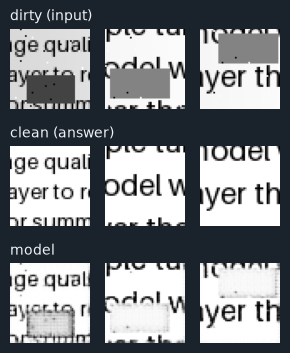

In [24]:
# 가장 나쁜 조각 3개 — 평가 문서 조각 256개(좌표 seed 7777 · P6 평가 조각과 같음) 가운데 모델 오차가 가장 큰 조각 · 줄마다 dirty · clean · model
assert globals().get("눈금_통과") and globals().get("글자칸_통과"), "[안내] 확인 ① · ② 에서 모두 통과를 받은 뒤 실행 · P8-1 · P8-2 셀을 다시 실행했으면 그 확인 셀도 다시 · 막히면 대체 셀"
erng = np.random.default_rng(7777)
EX, EY = [], []
for i in eval_ids:
    c, d = docs[i]
    for _ in range(32):
        y, x = int(erng.integers(0, H - PS + 1)), int(erng.integers(0, W - PS + 1))
        EX.append(crop(d, y, x))
        EY.append(crop(c, y, x))
EX, EY = to_batch(EX), to_batch(EY)
with torch.no_grad():
    EO = model_A(EX)
worst = ((EO - EY) ** 2).mean((1, 2, 3)).argsort(descending=True)[:3].tolist()   # 조각마다 평균 제곱 오차 → 큰 순서로 3개
show_rows([("dirty (input)", EX), ("clean (answer)", EY), ("model", EO)], worst)

## P8 마무리 — 적기 (채점 아님 · 1번은 필수)

이 칸을 두 번 눌러 `→` 뒤에 적음

1. (필수) 왜 글자 칸 표시를 clean 으로 만들었나 · 자기 말로 한 문장 → 
    - 채점의 기준이 되는 거니깐.
2. 문서 전체 점수와 글자 칸 점수가 다른 쪽을 가리킬 때 무엇을 믿나 · 까닭 → 
    - 노이즈가 문서 전체에 퍼져있으면 문서 전체를 봐야할 것 같고, 글자 부분에만 노이즈가 집중되어있으면 글자를 봐야할 것 같다. 
3. 정답(clean)이 없는 문서라면 무엇으로 판단하나 → 
    - 그러면 dirty를 기준으로 봐야할 것 같은데.....
4. 가장 나쁜 조각 그림에서 남은 것 → 
    - 노이즈의 색깔을 흰색으로 만들었다는 것 밖에는 변한게 없는 것 같다. 
5. 대체 셀을 썼나 · 썼다면 어디서 막혔나 →